In [77]:
import numpy as np
import matplotlib.pyplot as plt

data=np.load('Cell_2.npy', allow_pickle=True).item()
data.keys() 

lfp=data['LFP']
units=data['Unit']
SpikeTiming=data['SpikeTiming']
StimCond=data['StimCond']
Waveform=data['Waveform']



In [78]:
Unit_aligned = []
for i in range(0, len(StimCond)):
    Unit_aligned.append(units[StimCond[i,0]-50:StimCond[i,0]+200])


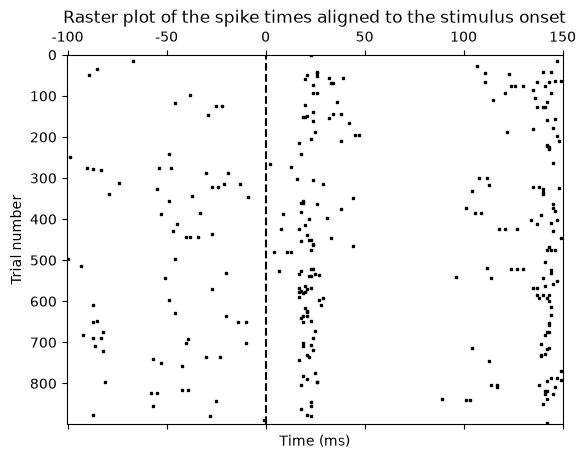

In [79]:
Unit_aligned = np.array(Unit_aligned)
plt.spy(Unit_aligned, markersize=1.5,aspect='auto',color='black')
plt.axvline(x=100, color='k', linestyle='--')
plt.xlabel('Time (ms)')
plt.ylabel('Trial number')
plt.title('Raster plot of the spike times aligned to the stimulus onset')
plt.xticks([0, 50, 100, 150, 200, 250], ['-100', '-50', '0', '50', '100', '150'])
plt.show()

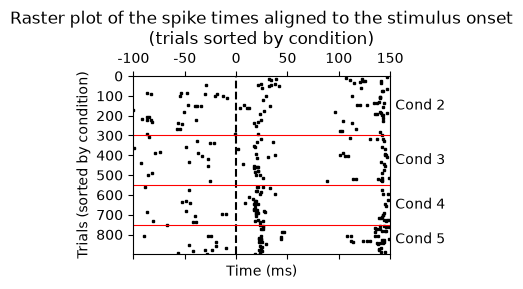

In [83]:
# sort trials by stimulus condition
order = np.argsort(StimCond[:, 1], kind='stable')
sorted_cond = StimCond[order, 1]
Unit_aligned_sorted = Unit_aligned[order]

fig, ax = plt.subplots(figsize=(4, 3))
ax.spy(Unit_aligned_sorted, markersize=1.5, aspect='auto', color='black')
ax.axvline(x=100, color='k', linestyle='--')

# separators between condition blocks
boundaries = np.where(np.diff(sorted_cond) != 0)[0] + 0.5
for b in boundaries:
    ax.axhline(y=b, color='red', linewidth=0.8)

# condition labels on the right-hand side
cond_ids, first_idx, counts = np.unique(sorted_cond, return_index=True, return_counts=True)
for c, start, n in zip(cond_ids, first_idx, counts):
    ax.text(Unit_aligned_sorted.shape[1] + 5, start + n / 2, f'Cond {int(c)}', va='center')

ax.set_xlabel('Time (ms)')
ax.set_ylabel('Trials (sorted by condition)')
ax.set_title('Raster plot of the spike times aligned to the stimulus onset\n(trials sorted by condition)')
ax.set_xticks([0, 50, 100, 150, 200, 250])
ax.set_xticklabels(['-100', '-50', '0', '50', '100', '150'])
plt.tight_layout()
plt.show()